<a href="https://colab.research.google.com/github/buvir/ab-testing-playbook/blob/main/ab_testing_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A/B Testing Playbook - Colab

In [ ]:
# Title & imports


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower, TTestIndPower
from sklearn.utils import resample

sns.set(style="whitegrid")
np.random.seed(42)


In [ ]:
# Option A: Generate synthetic dataset (quick)
def generate_synthetic_ab(n_users=20000, p_A=0.10, p_B=0.12, avg_revenue_A=20, avg_revenue_B=22, seed=42):
    np.random.seed(seed)
    n_A = n_users // 2
    n_B = n_users - n_A
    users = []
    # Group A
    conv_A = np.random.binomial(1, p_A, size=n_A)
    revenue_A = conv_A * np.random.exponential(avg_revenue_A, size=n_A)
    users += list(zip([ 'A' ]*n_A, conv_A, revenue_A))
    # Group B
    conv_B = np.random.binomial(1, p_B, size=n_B)
    revenue_B = conv_B * np.random.exponential(avg_revenue_B, size=n_B)
    users += list(zip([ 'B' ]*n_B, conv_B, revenue_B))
    df = pd.DataFrame(users, columns=['variant', 'converted', 'revenue'])
    df['user_id'] = np.arange(1, len(df)+1)
    return df.sample(frac=1, random_state=seed).reset_index(drop=True)

df = generate_synthetic_ab()
df.head()


,variant,converted,revenue,user_id
0,B,0,0.0,10651
1,A,0,0.0,2042
2,A,0,0.0,8669
3,A,0,0.0,1115
4,B,0,0.0,13903


CSV, upload and load like:

# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('your_ab_data.csv')
# df.head()


In [ ]:
# Quick EDA

df['variant'].value_counts(), df['converted'].mean()
# Conversion by group
agg = df.groupby('variant').agg(
    users=('user_id','count'),
    conversions=('converted','sum'),
    conv_rate = ('converted','mean'),
    avg_revenue = ('revenue','mean')
).reset_index()
agg




,variant,users,conversions,conv_rate,avg_revenue
0,A,10000,961,0.0961,1.938519
1,B,10000,1177,0.1177,2.532446


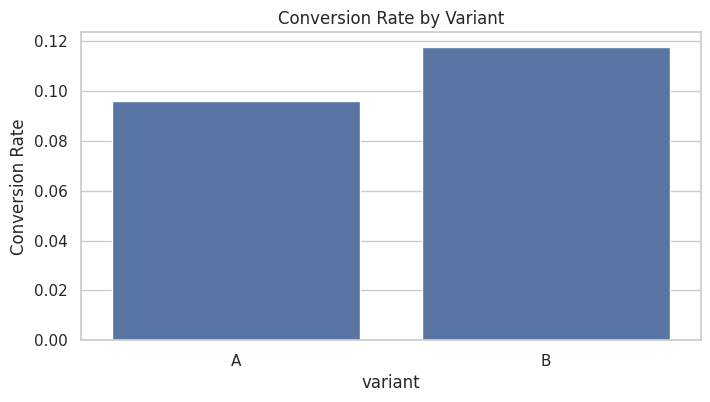

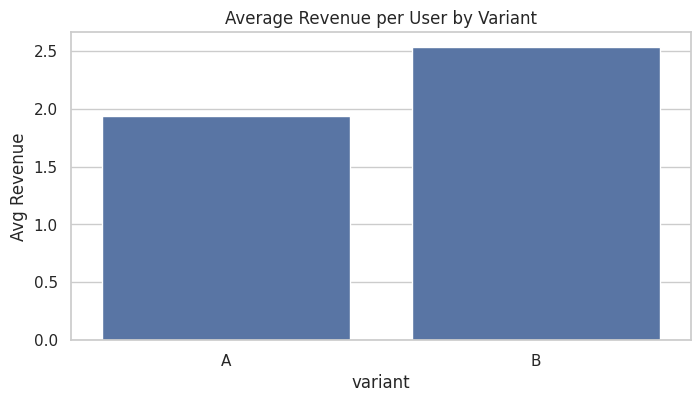

In [ ]:
# Visualization

plt.figure(figsize=(8,4))
sns.barplot(x='variant', y='conv_rate', data=agg)
plt.title('Conversion Rate by Variant')
plt.ylabel('Conversion Rate')
plt.show()

plt.figure(figsize=(8,4))
sns.barplot(x='variant', y='avg_revenue', data=agg)
plt.title('Average Revenue per User by Variant')
plt.ylabel('Avg Revenue')
plt.show()


In [ ]:
#Hypotheses (explicit)

print("Primary metric: conversion rate")
print("H0: conversion_rate_B <= conversion_rate_A")
print("H1: conversion_rate_B > conversion_rate_A (one-sided)")


Primary metric: conversion rate
H0: conversion_rate_B <= conversion_rate_A
H1: conversion_rate_B > conversion_rate_A (one-sided)


In [ ]:
# Statistical test: proportions z-test
count = agg['conversions'].values
nobs = agg['users'].values

# Using two-sided test by default; adjust alternative if needed
stat, pval = proportions_ztest(count, nobs, alternative='larger')  # 'two-sided' or 'larger'
print("z-stat:", stat, "p-value:", pval)


z-stat: -4.943105231228452 p-value: 0.9999996155602293


In [ ]:
# Confidence intervals for proportions (Wilson)

def proportion_ci(count, n, alpha=0.05):
    ci_low, ci_upp = sm.stats.proportion_confint(count, n, alpha=alpha, method='wilson')
    return ci_low, ci_upp

for i,row in agg.iterrows():
    low,upp = proportion_ci(row['conversions'], row['users'])
    print(f"Variant {row['variant']}: conv_rate={row['conv_rate']:.4f}, CI=({low:.4f}, {upp:.4f})")


Variant A: conv_rate=0.0961, CI=(0.0905, 0.1020)
Variant B: conv_rate=0.1177, CI=(0.1115, 0.1242)


In [ ]:
# Effect size & required sample size (conversion rate)
# Observed rates
p1 = agg.loc[agg['variant']=='A','conv_rate'].values[0]
p2 = agg.loc[agg['variant']=='B','conv_rate'].values[0]
effect_size = proportion_effectsize(p2, p1)  # Cohen's h
print("Observed p1 (A):", p1, "p2 (B):", p2, "Cohen's h:", effect_size)

power_analysis = NormalIndPower()
# compute required n per group for 80% power, alpha=0.05, two-sided default
n_per_group = power_analysis.solve_power(effect_size=effect_size, power=0.8, alpha=0.05, alternative='two-sided')
print("Estimated sample size per group for 80% power (two-sided):", np.ceil(n_per_group))


Observed p1 (A): 0.0961 p2 (B): 0.1177 Cohen's h: 0.06998979140307127
Estimated sample size per group for 80% power (two-sided): 3205.0


In [ ]:
# Uplift / ATE (simple)
ate = p2 - p1
relative_uplift = (p2 - p1) / p1 if p1>0 else np.nan
print(f"ATE (absolute uplift) = {ate:.4f}")
print(f"Relative uplift = {relative_uplift:.2%}")


ATE (absolute uplift) = 0.0216
Relative uplift = 22.48%


In [ ]:
# Revenue per user test (t-test with bootstrapped CI)
# Revenue per user (includes zeros for non-converters)
rev_A = df.loc[df['variant']=='A','revenue'].values
rev_B = df.loc[df['variant']=='B','revenue'].values
# t-test (unequal variance)
tstat, t_p = stats.ttest_ind(rev_B, rev_A, equal_var=False)
print("t-stat:", tstat, "p-value:", t_p)

# bootstrap difference in means (95% CI)
def bootstrap_mean_diff(a,b, n_boot=5000, seed=42):
    rng = np.random.RandomState(seed)
    diffs = []
    for _ in range(n_boot):
        a_s = rng.choice(a, size=len(a), replace=True)
        b_s = rng.choice(b, size=len(b), replace=True)
        diffs.append(b_s.mean() - a_s.mean())
    diffs = np.array(diffs)
    return np.percentile(diffs, [2.5, 97.5]), diffs.mean()

ci, mean_diff = bootstrap_mean_diff(rev_A, rev_B)
print("Bootstrap mean difference (B - A):", mean_diff, "95% CI:", ci)


t-stat: 4.491382345717821 p-value: 7.116816350784016e-06
Bootstrap mean difference (B - A): 0.5957868201622394 95% CI: [0.33808501 0.85778547]


In [ ]:
# Multiple testing & guardrails

print("If you have multiple metrics or segments, adjust for multiple comparisons (Bonferroni, BH).")


If you have multiple metrics or segments, adjust for multiple comparisons (Bonferroni, BH).


In [ ]:
# Quick sanity checks / diagnostics
# randomization check: covariate balance (if covariates exist)

# check missing & duplicate users
print("Missing values per column:\n", df.isna().sum())
print("Duplicate user_ids:", df['user_id'].duplicated().sum())

Missing values per column:
 variant      0
converted    0
revenue      0
user_id      0
dtype: int64
Duplicate user_ids: 0


In [ ]:
# Export results & short report
results = {
    'p_A': p1,
    'p_B': p2,
    'z_stat': float(stat),
    'p_value': float(pval),
    'ATE': float(ate),
    'relative_uplift': float(relative_uplift),
    't_stat_revenue': float(tstat),
    'p_revenue': float(t_p)
}
results_df = pd.DataFrame([results])
results_df.to_csv('ab_test_results_summary.csv', index=False)
print("Saved results to ab_test_results_summary.csv")
results_df


Saved results to ab_test_results_summary.csv


,p_A,p_B,z_stat,p_value,ATE,relative_uplift,t_stat_revenue,p_revenue
0,0.0961,0.1177,-4.943105,1.0,0.0216,0.224766,4.491382,0.000007


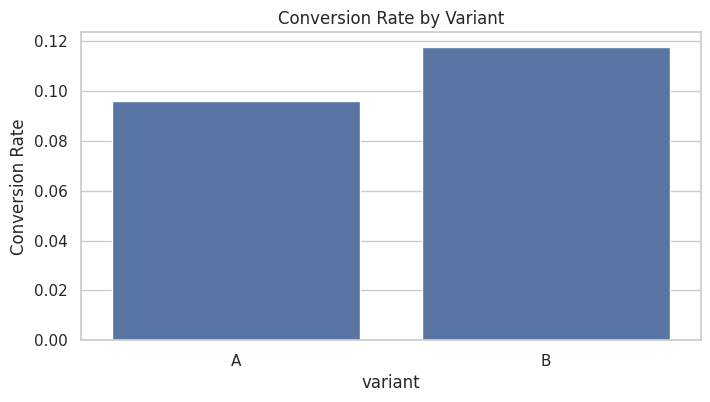

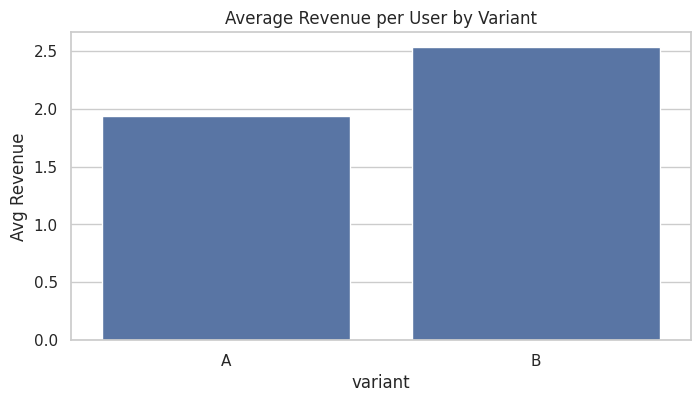

Charts saved to: /content/ab_testing_outputs


In [ ]:
# Save Charts in Colab
# Create an output directory inside Colab
import os

OUTPUT_DIR = "/content/ab_testing_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save previously generated charts
conv_chart_path = os.path.join(OUTPUT_DIR, "conversion_rate_chart.png")
rev_chart_path = os.path.join(OUTPUT_DIR, "revenue_chart.png")

# Re-plot and save Conversion chart
plt.figure(figsize=(8,4))
sns.barplot(x='variant', y='conv_rate', data=agg)
plt.title('Conversion Rate by Variant')
plt.ylabel('Conversion Rate')
plt.savefig(conv_chart_path, bbox_inches='tight')
plt.show()

# Re-plot and save Revenue chart
plt.figure(figsize=(8,4))
sns.barplot(x='variant', y='avg_revenue', data=agg)
plt.title('Average Revenue per User by Variant')
plt.ylabel('Avg Revenue')
plt.savefig(rev_chart_path, bbox_inches='tight')
plt.show()

print("Charts saved to:", OUTPUT_DIR)


In [ ]:
# Automatic Conclusion + Explanation of Charts
# Final Conclusion Generator

conv_A = agg.loc[agg['variant']=='A','conv_rate'].values[0]
conv_B = agg.loc[agg['variant']=='B','conv_rate'].values[0]

revenue_A = agg.loc[agg['variant']=='A','avg_revenue'].values[0]
revenue_B = agg.loc[agg['variant']=='B','avg_revenue'].values[0]

conclusion_text = ""

# Conversion findings
if pval < 0.05:
    if conv_B > conv_A:
        conversion_conclusion = (
            f"The A/B test shows that Variant B significantly outperforms Variant A "
            f"in conversion rate (A: {conv_A:.2%}, B: {conv_B:.2%}). "
            "The p-value is below 0.05, meaning the improvement is statistically significant."
        )
    else:
        conversion_conclusion = (
            f"Although the p-value is below 0.05, Variant B does not show a meaningful improvement "
            f"over Variant A in conversion rate (A: {conv_A:.2%}, B: {conv_B:.2%}). "
            "The statistical difference is likely driven by noise or inverse effect."
        )
else:
    conversion_conclusion = (
        f"The test does not provide sufficient evidence to conclude that Variant B improves conversion rate. "
        f"While A = {conv_A:.2%} and B = {conv_B:.2%}, the p-value ({pval:.4f}) is above 0.05."
    )

# Revenue findings (descriptive)
if t_p < 0.05:
    revenue_conclusion = (
        f"Variant B also shows a statistically significant difference in revenue per user "
        f"(A: ${revenue_A:.2f}, B: ${revenue_B:.2f}). "
        "The t-test suggests the revenue change is meaningful."
    )
else:
    revenue_conclusion = (
        f"Revenue differences are not statistically significant (A: ${revenue_A:.2f}, B: ${revenue_B:.2f})."
    )

# Chart explanations
chart_explanation = (
    "The conversion bar chart visualizes the proportion of users who converted in each group. "
    "A taller bar for Variant B indicates a higher conversion performance.\n\n"
    "The revenue per user chart shows the average earning generated by each user in both variants. "
    "This helps determine whether higher conversions also translate into higher monetary value."
)

# Combine everything
conclusion_text = (
    "### 📌 Final Conclusion\n"
    f"{conversion_conclusion}\n\n"
    f"{revenue_conclusion}\n\n"
    "### 📊 Chart Interpretation\n"
    f"{chart_explanation}\n\n"
    "### ✅ Business Recommendation\n"
)

# Business Recommendation
if pval < 0.05 and conv_B > conv_A:
    conclusion_text += (
        "Based on statistically significant improvements, Variant B is recommended for rollout. "
        "It shows a measurable positive impact on user conversion and may improve business KPIs."
    )
else:
    conclusion_text += (
        "Variant B should **not** be rolled out yet. Either collect more data, run the test longer, "
        "or explore potential segmentation effects before deciding."
    )

print(conclusion_text)


### 📌 Final Conclusion
The test does not provide sufficient evidence to conclude that Variant B improves conversion rate. While A = 9.61% and B = 11.77%, the p-value (1.0000) is above 0.05.

Variant B also shows a statistically significant difference in revenue per user (A: $1.94, B: $2.53). The t-test suggests the revenue change is meaningful.

### 📊 Chart Interpretation
The conversion bar chart visualizes the proportion of users who converted in each group. A taller bar for Variant B indicates a higher conversion performance.

The revenue per user chart shows the average earning generated by each user in both variants. This helps determine whether higher conversions also translate into higher monetary value.

### ✅ Business Recommendation
Variant B should **not** be rolled out yet. Either collect more data, run the test longer, or explore potential segmentation effects before deciding.
